<a href="https://colab.research.google.com/github/SmitPatil2004/gearbox-fault-detection-uct/blob/main/notebooks/01_gearbox_data_inspection_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
from pathlib import Path

for p in Path('/content/drive/MyDrive').rglob('*earbox*'):
    print(p, '|', f'{p.stat().st_size / 1_048_576:.1f} MB')

/content/drive/MyDrive/Colab Notebooks/01_gearbox_data_inspection.ipynb.ipynb | 0.0 MB
/content/drive/MyDrive/Colab Notebooks/01_gearbox_data_inspection (1).ipynb.ipynb | 0.0 MB
/content/drive/MyDrive/UCT/Project8_pdm_Predictive Maintenance of gearboxdata.zip | 40.4 MB


In [14]:
import zipfile

OUTER = Path('/content/drive/MyDrive/UCT/Project8_pdm_Predictive Maintenance of gearboxdata.zip')  # ← paste yours

with zipfile.ZipFile(OUTER) as z:
    z.extractall('/content/outer')

inner = next(Path('/content/outer').rglob('*.zip'))
print('Inner zip:', inner.name)

DEST = Path('/content/gearbox_data')
with zipfile.ZipFile(inner) as z:
    z.extractall(DEST)

print('Folders:', [p.name for p in DEST.iterdir()])

Inner zip: Project8_pdm_Predictive Maintenance of gearboxdata.zip
Folders: ['Healthy Data', 'Project8_pdm_Predictive Maintenance of gearboxdata', 'BrokenTooth Data']


In [15]:
files = sorted(DEST.rglob('*.txt'))

print('Total data files:', len(files))
for p in files:
    print(' ', p.relative_to(DEST))

Total data files: 20
  BrokenTooth Data/b30hz0.txt
  BrokenTooth Data/b30hz10.txt
  BrokenTooth Data/b30hz20.txt
  BrokenTooth Data/b30hz30.txt
  BrokenTooth Data/b30hz40.txt
  BrokenTooth Data/b30hz50.txt
  BrokenTooth Data/b30hz60.txt
  BrokenTooth Data/b30hz70.txt
  BrokenTooth Data/b30hz80.txt
  BrokenTooth Data/b30hz90.txt
  Healthy Data/h30hz0.txt
  Healthy Data/h30hz10.txt
  Healthy Data/h30hz20.txt
  Healthy Data/h30hz30.txt
  Healthy Data/h30hz40.txt
  Healthy Data/h30hz50.txt
  Healthy Data/h30hz60.txt
  Healthy Data/h30hz70.txt
  Healthy Data/h30hz80.txt
  Healthy Data/h30hz90.txt


In [17]:
import pandas as pd

COLS = ['a1', 'a2', 'a3', 'a4']

sample = pd.read_csv(files[0], sep='\t', header=None,
                     skiprows=1, usecols=[0, 1, 2, 3], names=COLS)

print('File:', files[0].name)
print('Shape:', sample.shape)
print('\nMissing:\n', sample.isnull().sum())
sample.head()

File: b30hz0.txt
Shape: (88320, 4)

Missing:
 a1    0
a2    0
a3    0
a4    0
dtype: int64


,a1,a2,a3,a4
0,2.350390,1.454870,-1.667080,-2.055610
1,2.452970,1.400100,-2.825100,0.984487
2,-0.241284,-0.267390,0.793540,0.605862
3,1.130270,-0.890918,0.696969,0.613068
4,-1.296140,0.980479,-1.130560,-0.346971


In [18]:
import re

records = []
for p in files:
    condition = 'Healthy' if 'Healthy' in p.parent.name else 'BrokenTooth'
    load = int(re.search(r'hz(\d+)', p.stem).group(1))
    n_rows = len(pd.read_csv(p, sep='\t', header=None, skiprows=1, usecols=[0]))
    records.append({'file': p.name, 'condition': condition,
                    'load': load, 'rows': n_rows})

catalogue = pd.DataFrame(records).sort_values(['condition', 'load'])
catalogue

,file,condition,load,rows
0,b30hz0.txt,BrokenTooth,0,88320
1,b30hz10.txt,BrokenTooth,10,111616
2,b30hz20.txt,BrokenTooth,20,114432
3,b30hz30.txt,BrokenTooth,30,89856
4,b30hz40.txt,BrokenTooth,40,94464
5,b30hz50.txt,BrokenTooth,50,94208
6,b30hz60.txt,BrokenTooth,60,95488
7,b30hz70.txt,BrokenTooth,70,100864
8,b30hz80.txt,BrokenTooth,80,110335
9,b30hz90.txt,BrokenTooth,90,105728


In [19]:
print(catalogue['condition'].value_counts(), '\n')
print('Rows per condition:')
print(catalogue.groupby('condition')['rows'].sum(), '\n')
print('Total rows:', catalogue['rows'].sum(), '\n')
print(pd.crosstab(catalogue['load'], catalogue['condition']))

condition
BrokenTooth    10
Healthy        10
Name: count, dtype: int64 

Rows per condition:
condition
BrokenTooth    1005311
Healthy        1015808
Name: rows, dtype: int64 

Total rows: 2021119 

condition  BrokenTooth  Healthy
load                           
0                    1        1
10                   1        1
20                   1        1
30                   1        1
40                   1        1
50                   1        1
60                   1        1
70                   1        1
80                   1        1
90                   1        1


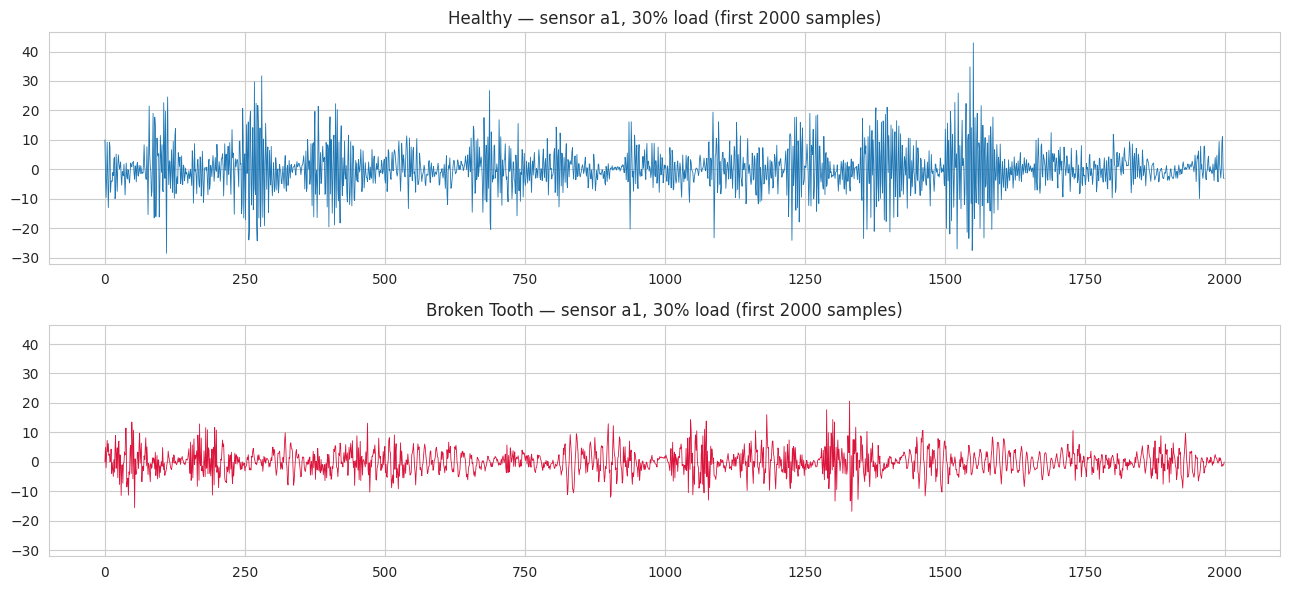

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

def load_file(name):
    p = next(DEST.rglob(name))
    return pd.read_csv(p, sep='\t', header=None, skiprows=1,
                       usecols=[0,1,2,3], names=COLS)

h = load_file('h30hz30.txt')
b = load_file('b30hz30.txt')      # same load level — fair comparison

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharey=True)
axes[0].plot(h['a1'][:2000], linewidth=0.6)
axes[0].set_title('Healthy — sensor a1, 30% load (first 2000 samples)')
axes[1].plot(b['a1'][:2000], linewidth=0.6, color='crimson')
axes[1].set_title('Broken Tooth — sensor a1, 30% load (first 2000 samples)')
plt.tight_layout()
plt.savefig('01_signal_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

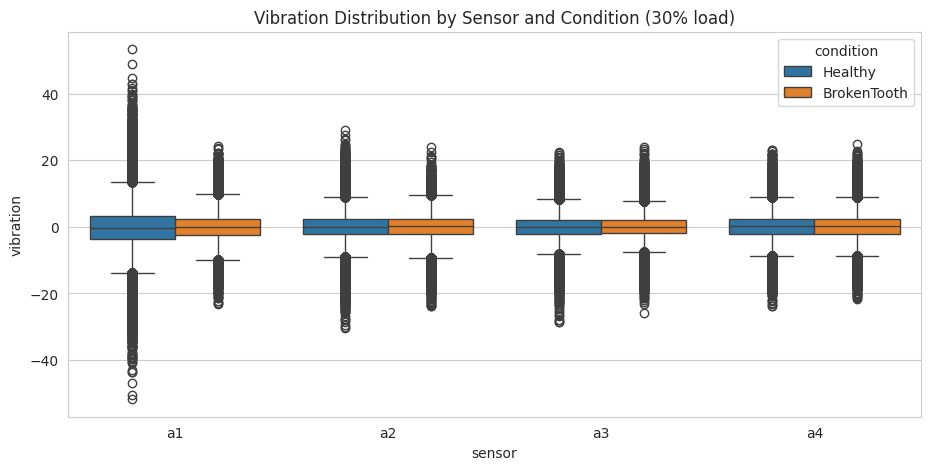

In [21]:
h2 = h.copy(); h2['condition'] = 'Healthy'
b2 = b.copy(); b2['condition'] = 'BrokenTooth'

melted = pd.concat([h2, b2]).melt(id_vars='condition', value_vars=COLS,
                                  var_name='sensor', value_name='vibration')

plt.figure(figsize=(11, 5))
sns.boxplot(data=melted, x='sensor', y='vibration', hue='condition')
plt.title('Vibration Distribution by Sensor and Condition (30% load)')
plt.savefig('02_sensor_distributions.png', dpi=120, bbox_inches='tight')
plt.show()